In [ ]:
!pip install pandas numpy openpyxl

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [ ]:


df = pd.read_csv("UP_EV_Forecasting_Dataset.csv")

print(df.head())

print(df.shape)

         date office_name office_code      fuel_type  registrations
0  2020-04-01    Agra Rto        UP80  Electric(Bov)             60
1  2020-08-01    Agra Rto        UP80  Electric(Bov)             78
2  2020-12-01    Agra Rto        UP80  Electric(Bov)            106
3  2020-02-01    Agra Rto        UP80  Electric(Bov)            154
4  2020-01-01    Agra Rto        UP80  Electric(Bov)            172
(4991, 5)


In [ ]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4991 entries, 0 to 4990
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           4991 non-null   object
 1   office_name    4991 non-null   object
 2   office_code    4991 non-null   object
 3   fuel_type      4991 non-null   object
 4   registrations  4991 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 195.1+ KB
None
       registrations
count    4991.000000
mean      146.169505
std       236.156249
min         1.000000
25%        21.000000
50%        69.000000
75%       173.000000
max      3836.000000
date             0
office_name      0
office_code      0
fuel_type        0
registrations    0
dtype: int64


In [ ]:
df["date"] = pd.to_datetime(df["date"])

In [ ]:
print(df.dtypes)

date             datetime64[ns]
office_name              object
office_code              object
fuel_type                object
registrations             int64
dtype: object


Check Registration value

In [ ]:
print(df["registrations"].describe())

count    4991.000000
mean      146.169505
std       236.156249
min         1.000000
25%        21.000000
50%        69.000000
75%       173.000000
max      3836.000000
Name: registrations, dtype: float64


In [ ]:
df = df[df["registrations"] >= 0]

Sorting data

In [ ]:
df = df.sort_values("date")

df.reset_index(drop=True, inplace=True)

Aggregate Monthly

In [ ]:
df["YearMonth"] = df["date"].dt.to_period("M")

In [ ]:
monthly_df = (
    df.groupby(
        ["YearMonth", "office_name"]
    )["registrations"]
    .sum()
    .reset_index()
)

In [ ]:
monthly_df["YearMonth"] = monthly_df["YearMonth"].dt.to_timestamp()

In [ ]:
monthly_df.rename(
    columns={
        "YearMonth":"date",
        "registrations":"monthly_registrations"
    },
    inplace=True
)

Create Time Features

In [ ]:
monthly_df["year"] = monthly_df["date"].dt.year

In [ ]:
monthly_df["month"] = monthly_df["date"].dt.month

In [ ]:
monthly_df["quarter"] = monthly_df["date"].dt.quarter

In [ ]:
monthly_df["month_name"] = monthly_df["date"].dt.month_name()

Lag Features

In [ ]:
monthly_df["lag_1"] = (
    monthly_df
    .groupby("office_name")["monthly_registrations"]
    .shift(1)
)

In [ ]:
monthly_df["lag_2"] = (
    monthly_df
    .groupby("office_name")["monthly_registrations"]
    .shift(2)
)

In [ ]:
monthly_df["lag_3"] = (
    monthly_df
    .groupby("office_name")["monthly_registrations"]
    .shift(3)
)

Rolling Mean

In [ ]:
monthly_df["rolling_mean_3"] = (
    monthly_df
    .groupby("office_name")["monthly_registrations"]
    .transform(
        lambda x: x.rolling(3).mean()
    )
)

Rolling Standard Deviation

In [ ]:
monthly_df["rolling_std_3"] = (
    monthly_df
    .groupby("office_name")["monthly_registrations"]
    .transform(
        lambda x: x.rolling(3).std()
    )
)

Growth Rate

In [ ]:
monthly_df["growth_rate"] = (
    monthly_df
    .groupby("office_name")["monthly_registrations"]
    .pct_change()
)

Fill Missing Values

In [ ]:
monthly_df = monthly_df.sort_values(["office_name", "date"])

feature_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_std_3",
    "growth_rate",
]

monthly_df[feature_cols] = (
    monthly_df.groupby("office_name")[feature_cols]
    .ffill()
    .fillna(0)
)

In [ ]:
print(monthly_df.head())

print(monthly_df.shape)

          date office_name  monthly_registrations  year  month  quarter  \
0   2019-01-01    Agra Rto                    170  2019      1        1   
72  2019-02-01    Agra Rto                    138  2019      2        1   
144 2019-03-01    Agra Rto                    168  2019      3        1   
218 2019-04-01    Agra Rto                    195  2019      4        2   
292 2019-05-01    Agra Rto                    152  2019      5        2   

    month_name  lag_1  lag_2  lag_3  rolling_mean_3  rolling_std_3  \
0      January    0.0    0.0    0.0        0.000000       0.000000   
72    February  170.0    0.0    0.0        0.000000       0.000000   
144      March  138.0  170.0    0.0      158.666667      17.925773   
218      April  168.0  138.0  170.0      167.000000      28.513155   
292        May  195.0  168.0  138.0      171.666667      21.733231   

     growth_rate  
0       0.000000  
72     -0.188235  
144     0.217391  
218     0.160714  
292    -0.220513  
(4731, 13)


In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs("processed_data", exist_ok=True)

monthly_df.to_csv(
    "processed_data/monthly_ev_registrations.csv",
    index=False
)

In [ ]:
print(monthly_df.sample(10))

           date                     office_name  monthly_registrations  year  \
4323 2023-12-01                          Mahoba                    111  2023   
3101 2022-08-01        Kasganj(Kashi Ram Nagar)                     15  2022   
2434 2021-11-01           Padrauna(Kushi Nagar)                     46  2021   
3247 2022-10-01                         Jaunpur                    119  2022   
2579 2022-01-01                             Mau                     97  2022   
2194 2021-08-01        Kasganj(Kashi Ram Nagar)                      7  2021   
4701 2024-05-01  Mahanagar Arto Lucknow (Up321)                    252  2024   
976  2020-02-01                       Fathehpur                     72  2020   
218  2019-04-01                        Agra Rto                    195  2019   
1727 2021-01-01                       Sultanpur                     74  2021   

      month  quarter month_name  lag_1  lag_2  lag_3  rolling_mean_3  \
4323     12        4   December  100.0   93.0  

In [ ]:
df = pd.read_csv("processed_data/monthly_ev_registrations.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,office_name,monthly_registrations,year,month,quarter,month_name,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,growth_rate
0,2019-01-01,Agra Rto,170,2019,1,1,January,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,2019-02-01,Agra Rto,138,2019,2,1,February,170.0,0.0,0.0,0.000000,0.000000,-0.188235
2,2019-03-01,Agra Rto,168,2019,3,1,March,138.0,170.0,0.0,158.666667,17.925773,0.217391
3,2019-04-01,Agra Rto,195,2019,4,2,April,168.0,138.0,170.0,167.000000,28.513155,0.160714
4,2019-05-01,Agra Rto,152,2019,5,2,May,195.0,168.0,138.0,171.666667,21.733231,-0.220513


In [ ]:
print("Total Offices :", df["office_name"].nunique())

print(df["office_name"].unique())

Total Offices : 76
['Agra Rto' 'Akbarpur(Ambedkar Nagar)' 'Aligarh Rto' 'Amethi Arto'
 'Arto Office Rampur' 'Auraiya' 'Ayodhya Rto' 'Azamgarh Rto' 'Badaun'
 'Baghpat' 'Bahraich' 'Ballia' 'Balrampur' 'Bandarto' 'Barabanki Arto'
 'Bareilly' 'Basti Rto' 'Bhadohi(Sant Ravidas Nagar)' 'Bijnor'
 'Bulandshahar' 'Chandauli' 'Chitrakoot' 'Deoria' 'Etah' 'Etawah'
 'Farrukhabad' 'Fathehpur' 'Ferozabad' 'Ghaziabad' 'Ghazipur' 'Gonda'
 'Gorakhpur Rto' 'Hamirpur(Up)' 'Hapur' 'Hardoi' 'Hathras' 'Jaunpur'
 'Jhansirto' 'Jpnagar' 'Kannauj' 'Kanpur Dehat' 'Kanpur Nagar'
 'Kasganj(Kashi Ram Nagar)' 'Kaushambi' 'Lakhimpur Kheri' 'Lalitpur'
 'Mahanagar Arto Lucknow (Up321)' 'Maharajganj' 'Mahoba' 'Mainpuri'
 'Mathura' 'Mau' 'Meerut Rto' 'Mirzapur Rto' 'Moradabad' 'Muzaffarnagar'
 'Noida' 'Orai' 'Padrauna(Kushi Nagar)' 'Pilibhit' 'Pratapgarh'
 'Prayagraj Rto' 'Raibareilly' 'Saharanpur Rto' 'Sahjahanpur'
 'Sambhal Arto' 'Sant Kabir Nagar' 'Shamli Arto' 'Shravasti'
 'Siddharth Nagar(Naugarh)' 'Sitapur' 'Sonbha

Total EV Registrations

In [ ]:
print("Total EV Registrations")

print(df["monthly_registrations"].sum())

Total EV Registrations
729532


Monthly Trend

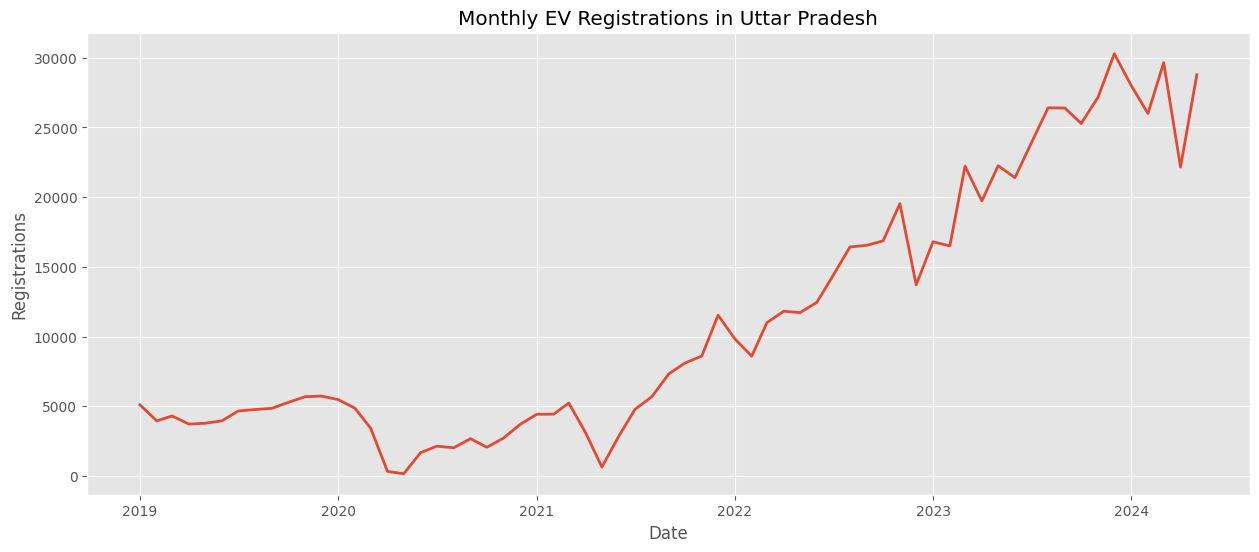

In [ ]:
monthly = (
    df.groupby("date")["monthly_registrations"]
      .sum()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly.index,
    monthly.values,
    linewidth=2
)

plt.title("Monthly EV Registrations in Uttar Pradesh")

plt.xlabel("Date")

plt.ylabel("Registrations")

plt.grid(True)

plt.show()

Top 15 Districts

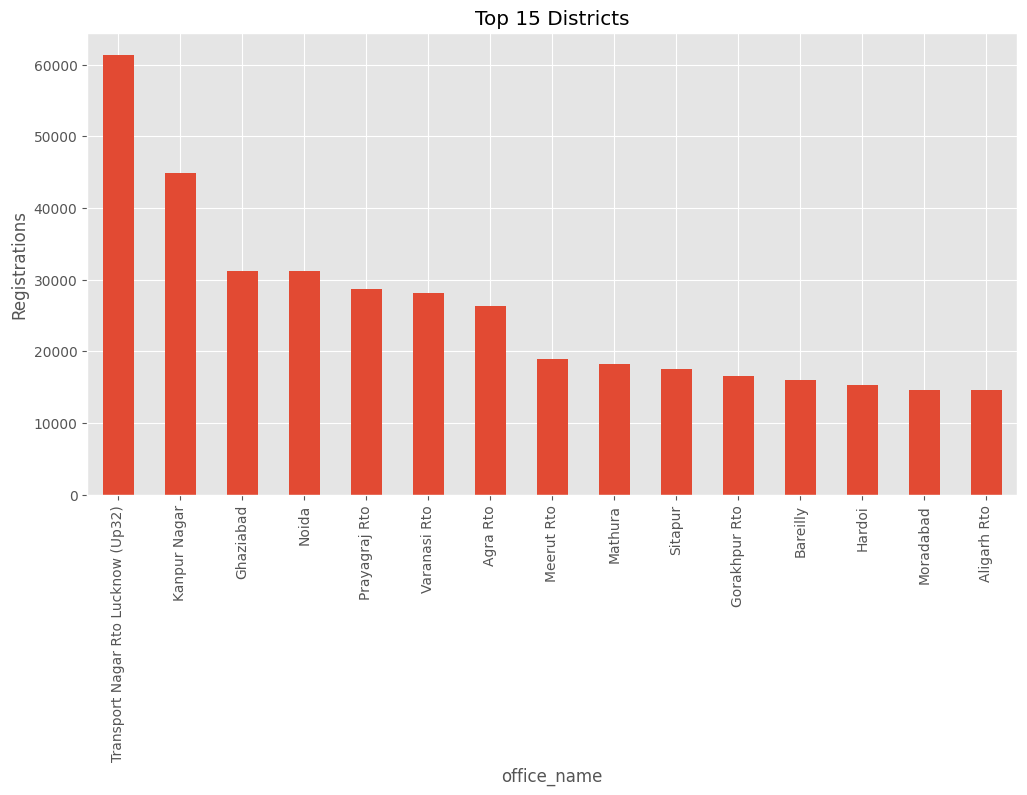

In [ ]:
top15 = (
    df.groupby("office_name")["monthly_registrations"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

top15.plot(kind="bar")

plt.title("Top 15 Districts")

plt.ylabel("Registrations")

plt.show()

Bottom 15 Districts

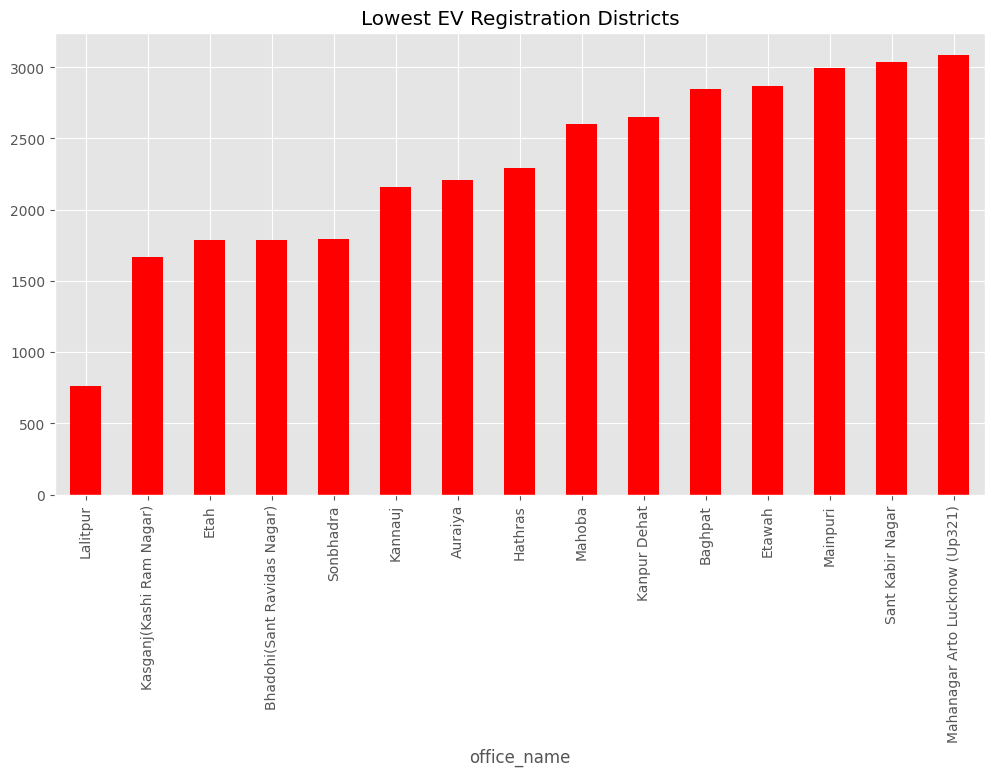

In [ ]:
bottom15 = (
    df.groupby("office_name")["monthly_registrations"]
      .sum()
      .sort_values()
      .head(15)
)

plt.figure(figsize=(12,6))

bottom15.plot(kind="bar", color="red")

plt.title("Lowest EV Registration Districts")

plt.show()

Top 5 District Trends

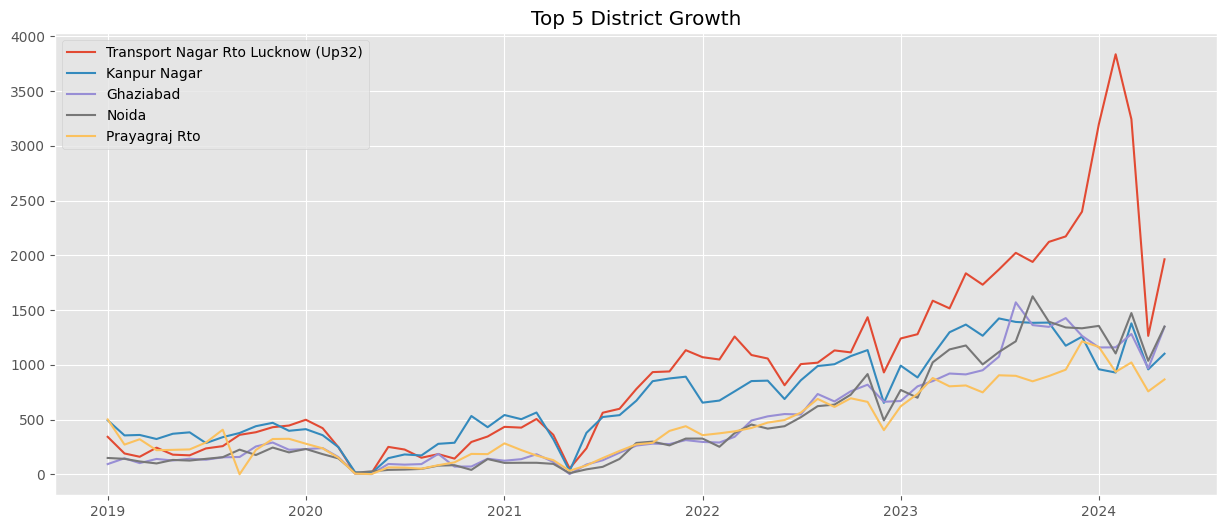

In [ ]:
top5 = top15.index[:5]

plt.figure(figsize=(15,6))

for office in top5:

    temp = df[df["office_name"] == office]

    plt.plot(
        temp["date"],
        temp["monthly_registrations"],
        label=office
    )

plt.legend()

plt.title("Top 5 District Growth")

plt.show()

Distribution

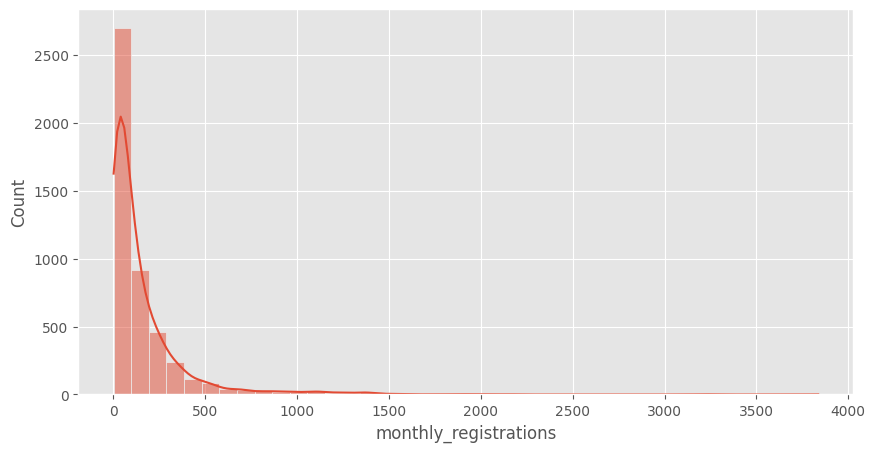

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["monthly_registrations"],
    bins=40,
    kde=True
)

plt.show()

Boxplot

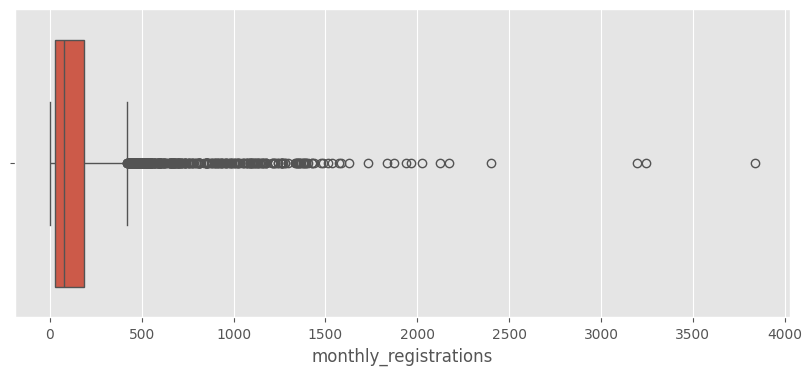

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["monthly_registrations"]
)

plt.show()

Heatmap

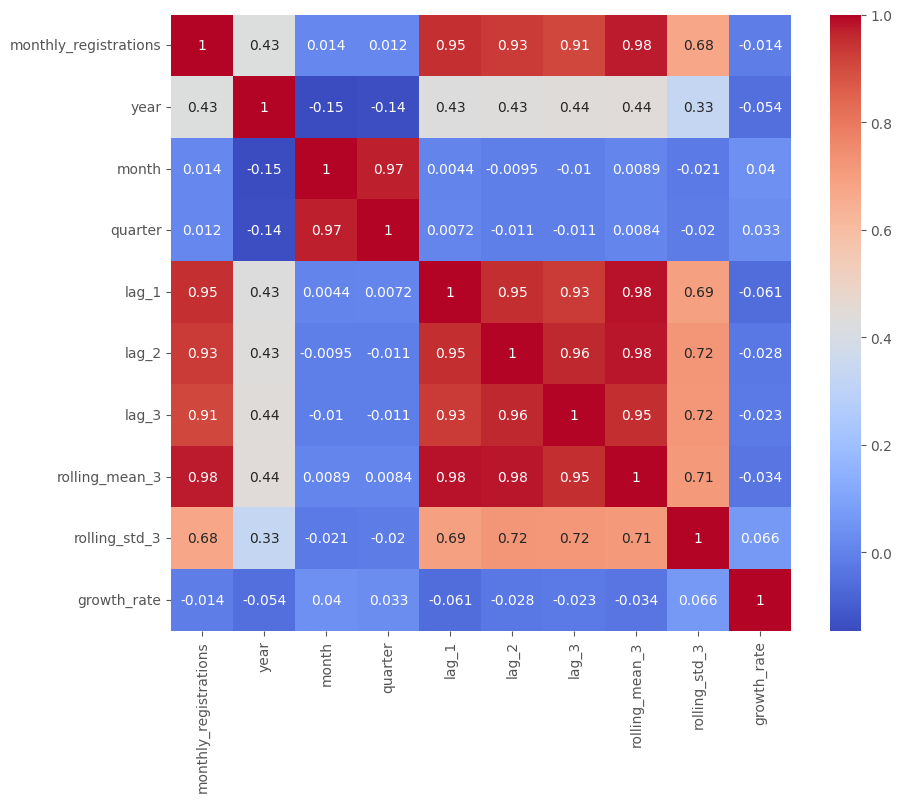

In [ ]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

Quarterly Trend

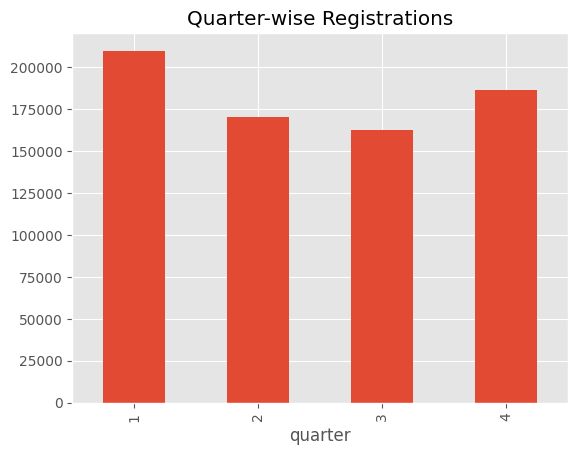

In [ ]:
quarter = (
    df.groupby("quarter")["monthly_registrations"]
      .sum()
)

quarter.plot(kind="bar")

plt.title("Quarter-wise Registrations")

plt.show()

Average Monthly Registrations

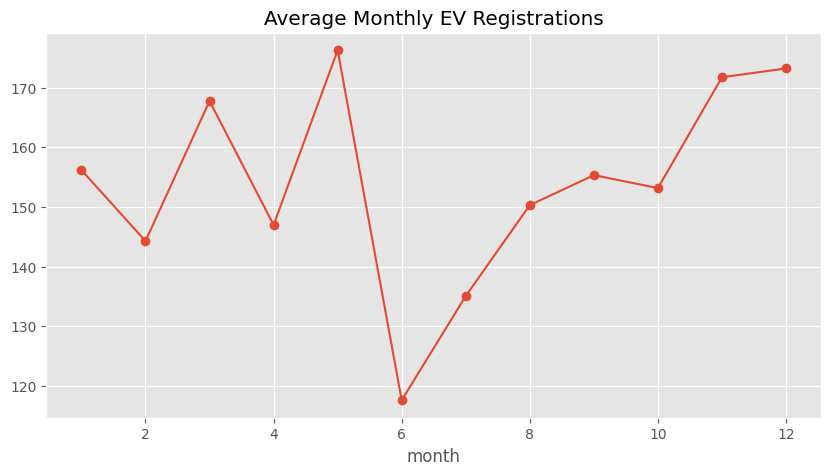

In [ ]:
avg = (
    df.groupby("month")["monthly_registrations"]
      .mean()
)

avg.plot(
    marker="o",
    figsize=(10,5)
)

plt.grid(True)

plt.title("Average Monthly EV Registrations")

plt.show()

Growth Rate Distribution

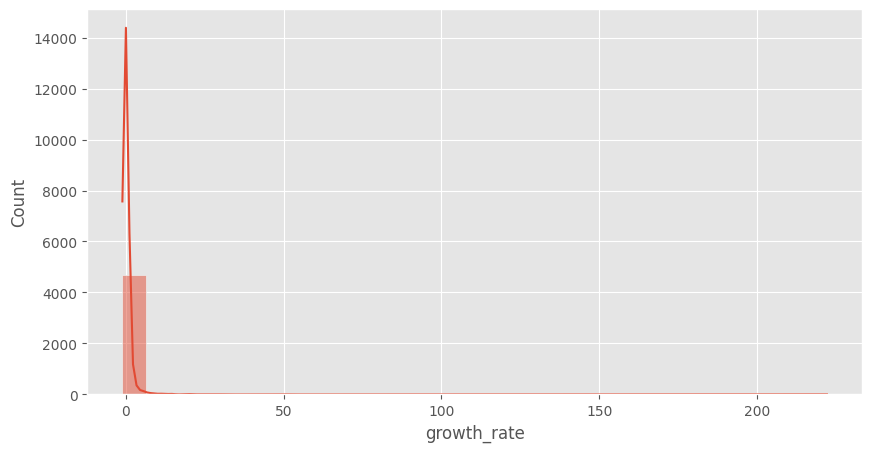

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["growth_rate"],
    bins=30,
    kde=True
)

plt.show()

In [ ]:
df.to_csv(
    "processed_data/final_model_dataset.csv",
    index=False
)

Code update(Part 3)

Model Preparation


In [ ]:
df = pd.read_csv("processed_data/final_model_dataset.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,office_name,monthly_registrations,year,month,quarter,month_name,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,growth_rate
0,2019-01-01,Agra Rto,170,2019,1,1,January,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,2019-02-01,Agra Rto,138,2019,2,1,February,170.0,0.0,0.0,0.000000,0.000000,-0.188235
2,2019-03-01,Agra Rto,168,2019,3,1,March,138.0,170.0,0.0,158.666667,17.925773,0.217391
3,2019-04-01,Agra Rto,195,2019,4,2,April,168.0,138.0,170.0,167.000000,28.513155,0.160714
4,2019-05-01,Agra Rto,152,2019,5,2,May,195.0,168.0,138.0,171.666667,21.733231,-0.220513


In [ ]:
feature_columns = [
    "year",
    "month",
    "quarter",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_std_3",
    "growth_rate"
]

target_column = "monthly_registrations"

In [ ]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(df[feature_columns])

y_scaled = target_scaler.fit_transform(
    df[[target_column]]
)

In [ ]:
df = df.sort_values(["office_name", "date"]).reset_index(drop=True)

In [ ]:
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(feature_scaler,
            "models/feature_scaler.pkl")

joblib.dump(target_scaler,
            "models/target_scaler.pkl")

['models/target_scaler.pkl']

Sequence Generation

Improved Chronological Split

In [ ]:
X_train = []
y_train = []

X_test = []
y_test = []

In [ ]:
sequence_length = 12

for office in df["office_name"].unique():

    office_df = (
        df[df["office_name"] == office]
        .sort_values("date")
        .reset_index(drop=True)
    )

    X_office = feature_scaler.transform(
        office_df[feature_columns]
    )

    y_office = target_scaler.transform(
        office_df[[target_column]]
    )

    office_X = []
    office_y = []

    for i in range(sequence_length, len(office_df)):

        office_X.append(
            X_office[i-sequence_length:i]
        )

        office_y.append(
            y_office[i]
        )

    office_X = np.array(office_X)
    office_y = np.array(office_y)

    split = int(len(office_X) * 0.80)

    X_train.extend(office_X[:split])
    y_train.extend(office_y[:split])

    X_test.extend(office_X[split:])
    y_test.extend(office_y[split:])

In [ ]:
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Samples : (3015, 12, 9)
Testing Samples : (804, 12, 9)
Training Target : (3015, 1)
Testing Target : (804, 1)


Build the LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

Create the Model

In [ ]:
model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(16, activation="relu"))

model.add(Dense(1))

In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
os.makedirs("models", exist_ok=True)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="models/lstm_ev_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0028 - mae: 0.0349
Epoch 1: val_loss improved from None to 0.00193, saving model to models/lstm_ev_model.keras

Epoch 1: finished saving model to models/lstm_ev_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - loss: 0.0015 - mae: 0.0241 - val_loss: 0.0019 - val_mae: 0.0238
Epoch 2/100
92/95 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.7788e-04 - mae: 0.0149
Epoch 2: val_loss did not improve from 0.00193
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 5.9364e-04 - mae: 0.0151 - val_loss: 0.0028 - val_mae: 0.0304
Epoch 3/100
93/95 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.0417e-04 - mae: 0.0138
Epoch 3: val_loss improved from 0.00193 to 0.00191, saving model to models/lstm_ev_model.keras

Epoch 3: finished saving model to models/lstm_ev_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 4.8170e-04 - mae: 0.0135 - val_loss: 0.0019 - val_mae: 0.0221
Epoch 4/100
92/95 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4.25

In [ ]:
model.save("models/final_lstm_model.keras")

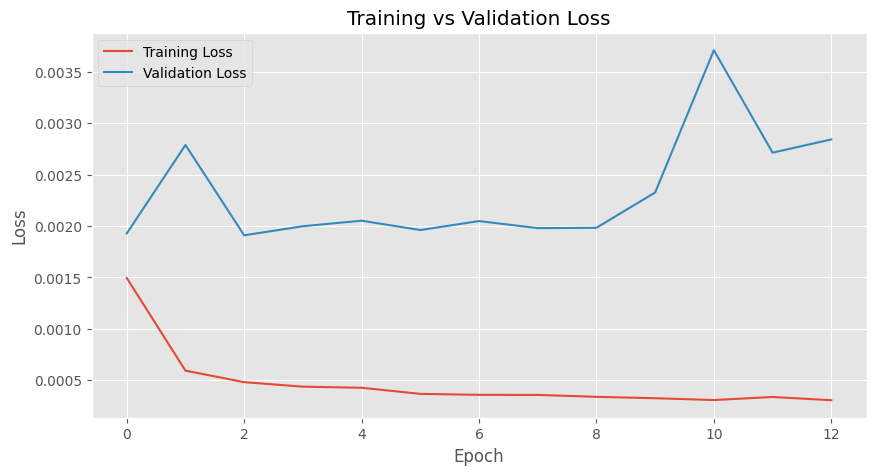

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

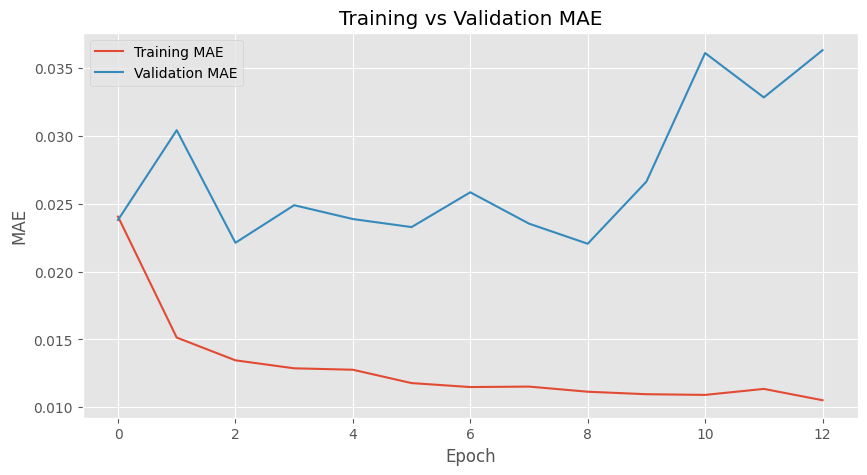

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
y_pred_scaled = model.predict(X_test)
y_pred = target_scaler.inverse_transform(y_pred_scaled)

y_actual = target_scaler.inverse_transform(y_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [ ]:
prediction_df = pd.DataFrame({
    "Actual": y_actual.flatten(),
    "Predicted": y_pred.flatten()
})

prediction_df.head(10)

,Actual,Predicted
0,1072.0,822.547913
1,1087.0,882.377258
2,1268.0,940.585754
3,1125.0,1000.397827
4,1375.0,1060.030762
5,1207.0,1113.300171
6,1486.0,1163.932495
7,470.0,1238.502808
8,1101.0,1334.535767
9,700.0,1414.472168


Model Evaluation

In [ ]:
# from sklearn.metrics import (
#    mean_absolute_error,
#     mean_squared_error,
#     r2_score
# )

# import numpy as np

In [ ]:
mae = mean_absolute_error(y_actual, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_actual, y_pred)
)

r2 = r2_score(y_actual, y_pred)

mape = np.mean(
    np.abs((y_actual - y_pred) / (y_actual + 1e-8))
) * 100

In [ ]:
print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"MAPE : {mape:.2f}%")

print(f"R² Score : {r2:.4f}")

MAE  : 84.84
RMSE : 167.59
MAPE : 25.92%
R² Score : 0.8152


Visualization

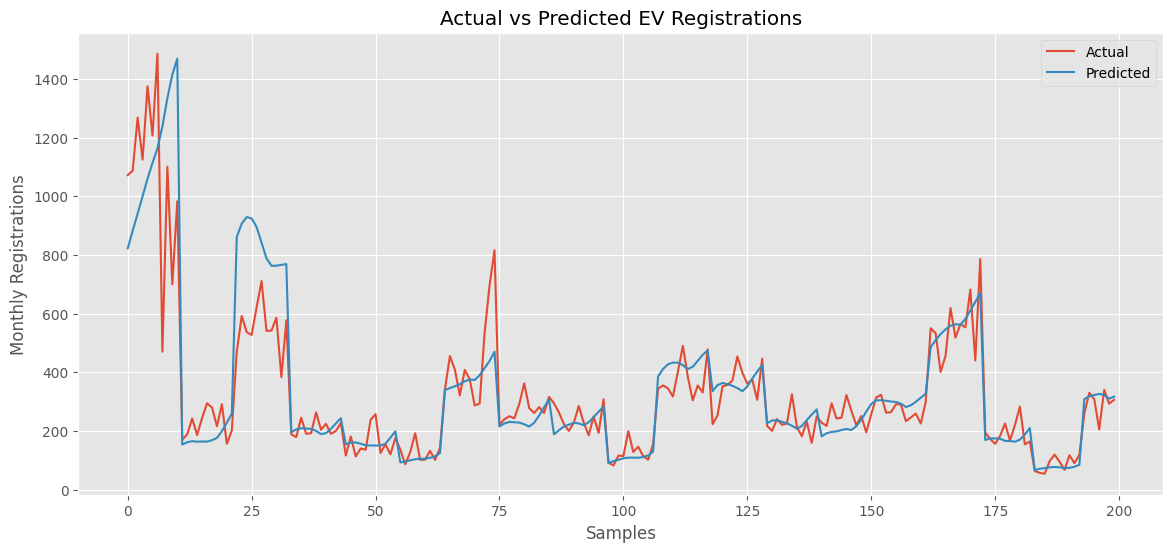

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    y_actual[:200],
    label="Actual"
)

plt.plot(
    y_pred[:200],
    label="Predicted"
)

plt.title("Actual vs Predicted EV Registrations")
plt.xlabel("Samples")
plt.ylabel("Monthly Registrations")
plt.legend()
plt.grid(True)

plt.show()

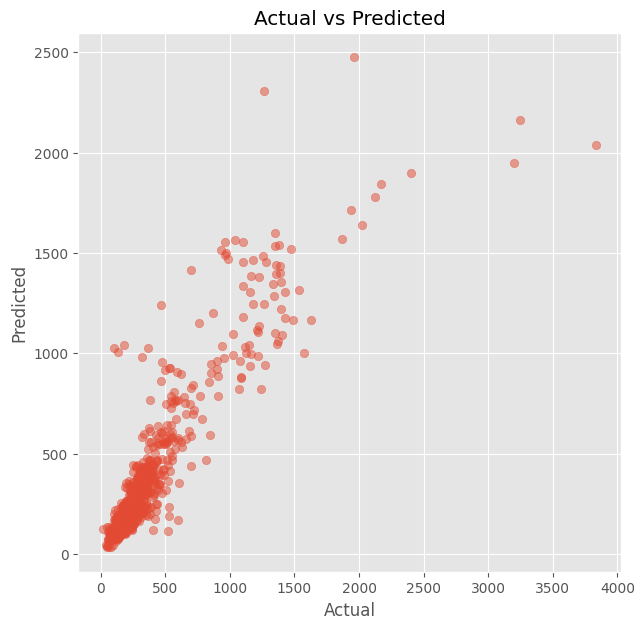

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

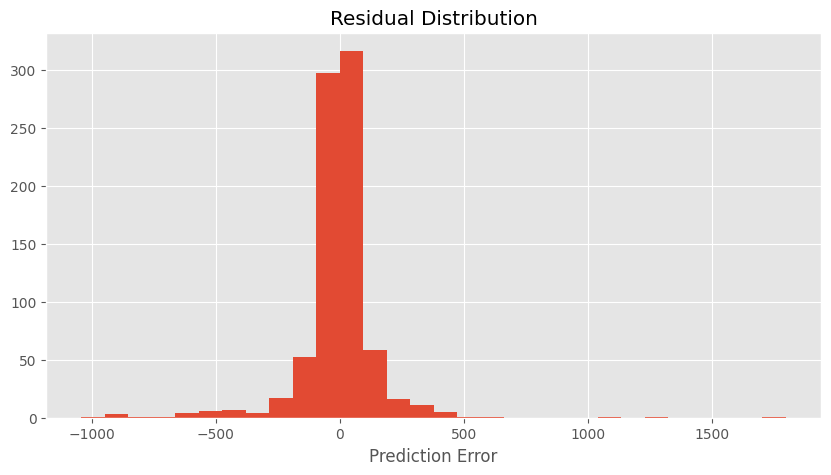

In [ ]:
residuals = y_actual.flatten() - y_pred.flatten()

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=30
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

Save Results

In [ ]:
prediction_df.to_csv(
    "processed_data/test_predictions.csv",
    index=False
)

In [ ]:
print("="*60)
print("LSTM Model Training Completed Successfully")
print("="*60)

print("Model Saved : models/final_lstm_model.keras")
print("Predictions Saved : processed_data/test_predictions.csv")

LSTM Model Training Completed Successfully
Model Saved : models/final_lstm_model.keras
Predictions Saved : processed_data/test_predictions.csv


In [ ]:
last_sequences = {}

for office in df["office_name"].unique():

    office_df = (
        df[df["office_name"] == office]
        .sort_values("date")
        .reset_index(drop=True)
    )

    office_features = feature_scaler.transform(
        office_df[feature_columns]
    )

    last_sequence = office_features[-sequence_length:]

    last_sequences[office] = last_sequence

In [ ]:
print("Total Districts :", len(last_sequences))

first_office = list(last_sequences.keys())[0]

print("First District :", first_office)

print("Sequence Shape :", last_sequences[first_office].shape)

Total Districts : 76
First District : Agra Rto
Sequence Shape : (12, 9)


In [ ]:
import joblib

joblib.dump(
    last_sequences,
    "models/last_sequences.pkl"
)

print("Last sequences saved successfully.")

Last sequences saved successfully.


In [ ]:
joblib.dump(
    feature_columns,
    "models/feature_columns.pkl"
)

['models/feature_columns.pkl']

In [ ]:
metadata = {
    "sequence_length": sequence_length,
    "target_column": target_column
}

joblib.dump(
    metadata,
    "models/model_metadata.pkl"
)

['models/model_metadata.pkl']

In [ ]:
last_dates = (
    df.groupby("office_name")["date"]
      .max()
      .to_dict()
)

joblib.dump(
    last_dates,
    "models/last_dates.pkl"
)

print("Last dates saved successfully.")

Last dates saved successfully.


In [ ]:
history_dict = {}

for office in df["office_name"].unique():

    office_history = (
        df[df["office_name"] == office]
        .sort_values("date")
        .tail(12)
        .copy()
    )

    history_dict[office] = office_history

In [ ]:
print("Total Districts :", len(history_dict))

first_office = list(history_dict.keys())[0]

history_dict[first_office]

Total Districts : 76


,date,office_name,monthly_registrations,year,month,quarter,month_name,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,growth_rate
53,2023-06-01,Agra Rto,983,2023,6,2,June,985.0,716.0,814.0,894.666667,154.733104,-0.002030
54,2023-07-01,Agra Rto,1072,2023,7,3,July,983.0,985.0,716.0,1013.333333,50.816664,0.090539
55,2023-08-01,Agra Rto,1087,2023,8,3,August,1072.0,983.0,985.0,1047.333333,56.216842,0.013993
56,2023-09-01,Agra Rto,1268,2023,9,3,September,1087.0,1072.0,983.0,1142.333333,109.088649,0.166513
57,2023-10-01,Agra Rto,1125,2023,10,4,October,1268.0,1087.0,1072.0,1160.000000,95.441081,-0.112776
58,2023-11-01,Agra Rto,1375,2023,11,4,November,1125.0,1268.0,1087.0,1256.000000,125.431256,0.222222
59,2023-12-01,Agra Rto,1207,2023,12,4,December,1375.0,1125.0,1268.0,1235.666667,127.441490,-0.122182
60,2024-01-01,Agra Rto,1486,2024,1,1,January,1207.0,1375.0,1125.0,1356.000000,140.467078,0.231152
61,2024-02-01,Agra Rto,470,2024,2,1,February,1486.0,1207.0,1375.0,1054.333333,524.923169,-0.683715
62,2024-03-01,Agra Rto,1101,2024,3,1,March,470.0,1486.0,1207.0,1019.000000,512.939568,1.342553


In [ ]:
joblib.dump(
    history_dict,
    "models/history_dict.pkl"
)

print("History saved successfully.")

History saved successfully.


District-wise EV Forecasting(part4)

In [ ]:
feature_scaler = joblib.load("models/feature_scaler.pkl")

target_scaler = joblib.load("models/target_scaler.pkl")
history_dict = joblib.load("models/history_dict.pkl")

metadata = joblib.load("models/model_metadata.pkl")

feature_columns = joblib.load("models/feature_columns.pkl")

In [ ]:
sequence_length = metadata["sequence_length"]

target_column = metadata["target_column"]

In [ ]:
print("Districts :", len(history_dict))

print("Sequence Length :", sequence_length)

Districts : 76
Sequence Length : 12


Create Feature Generator

In [ ]:
def build_feature_vector(history_df):

    history_df = history_df.sort_values("date")

    latest = history_df.iloc[-1]

    lag_1 = history_df["monthly_registrations"].iloc[-1]
    lag_2 = history_df["monthly_registrations"].iloc[-2]
    lag_3 = history_df["monthly_registrations"].iloc[-3]

    rolling_mean = (
        history_df["monthly_registrations"]
        .tail(3)
        .mean()
    )

    rolling_std = (
        history_df["monthly_registrations"]
        .tail(3)
        .std()
    )

    growth_rate = (
        (lag_1 - lag_2)
        /
        (lag_2 + 1e-8)
    )

    next_date = latest["date"] + pd.DateOffset(months=1)

    return pd.DataFrame({

        "year":[next_date.year],

        "month":[next_date.month],

        "quarter":[next_date.quarter],

        "lag_1":[lag_1],

        "lag_2":[lag_2],

        "lag_3":[lag_3],

        "rolling_mean_3":[rolling_mean],

        "rolling_std_3":[rolling_std],

        "growth_rate":[growth_rate]

    })

In [ ]:
first_office = list(history_dict.keys())[0]

sample = build_feature_vector(
    history_dict[first_office]
)

sample

,year,month,quarter,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,growth_rate
0,2024,6,2,983,700,1101,928.0,206.080082,0.404286


Forecast One Month

In [ ]:
def predict_next_month(history_df):

    feature_df = build_feature_vector(
        history_df
    )

    scaled = feature_scaler.transform(
        feature_df
    )

    sequence = np.repeat(
        scaled,
        sequence_length,
        axis=0
    )

    sequence = sequence.reshape(
        1,
        sequence_length,
        len(feature_columns)
    )

    prediction = model.predict(
        sequence,
        verbose=0
    )

    prediction = target_scaler.inverse_transform(
        prediction
    )[0][0]

    return max(0, prediction)

In [ ]:
predict_next_month(
    history_dict[first_office]
)

np.float32(1274.4048)

In [103]:
forecast_results = []

In [104]:
for district in history_dict.keys():

    history = history_dict[district].copy()

    for month in range(12):

        prediction = predict_next_month(history)

        last_date = history["date"].max()

        next_date = last_date + pd.DateOffset(months=1)

        forecast_results.append({

            "office_name": district,

            "date": next_date,

            "monthly_registrations": prediction

        })

        new_row = pd.DataFrame([{

            "date": next_date,

            "office_name": district,

            "monthly_registrations": prediction,

            "year": next_date.year,

            "month": next_date.month,

            "quarter": next_date.quarter,

            "month_name": next_date.strftime("%B")

        }])

        history = pd.concat(
            [history, new_row],
            ignore_index=True
        )

        history["lag_1"] = history["monthly_registrations"].shift(1)
        history["lag_2"] = history["monthly_registrations"].shift(2)
        history["lag_3"] = history["monthly_registrations"].shift(3)

        history["rolling_mean_3"] = (
            history["monthly_registrations"]
            .rolling(3)
            .mean()
        )

        history["rolling_std_3"] = (
            history["monthly_registrations"]
            .rolling(3)
            .std()
        )

        history["growth_rate"] = (
            history["monthly_registrations"]
            .pct_change()
        )

        history = history.fillna(0)

In [105]:
forecast_df = pd.DataFrame(forecast_results)

forecast_df.head()

,office_name,date,monthly_registrations
0,Agra Rto,2024-06-01,1274.404785
1,Agra Rto,2024-07-01,1355.506592
2,Agra Rto,2024-08-01,1514.481323
3,Agra Rto,2024-09-01,1624.916992
4,Agra Rto,2024-10-01,1711.931274


In [106]:
forecast_df.shape

(912, 3)

In [107]:
forecast_df.to_csv(

    "forecast_results.csv",

    index=False

)

print("Forecast CSV Saved Successfully.")

Forecast CSV Saved Successfully.


In [108]:
district_summary = (

    forecast_df

    .groupby("office_name")["monthly_registrations"]

    .sum()

    .reset_index()

)

In [109]:
district_summary.columns = [

    "District",

    "Forecasted EV Registrations"

]

In [110]:
district_summary = district_summary.sort_values(

    "Forecasted EV Registrations",

    ascending=False

)

district_summary.head(10)

,District,Forecasted EV Registrations
73,Transport Nagar Rto Lucknow (Up32),29986.685547
75,Varanasi Rto,24668.109375
56,Noida,24519.812500
28,Ghaziabad,23950.947266
41,Kanpur Nagar,23565.933594
0,Agra Rto,21703.355469
61,Prayagraj Rto,20598.656250
6,Ayodhya Rto,17939.904297
15,Bareilly,17727.332031
52,Meerut Rto,17213.335938


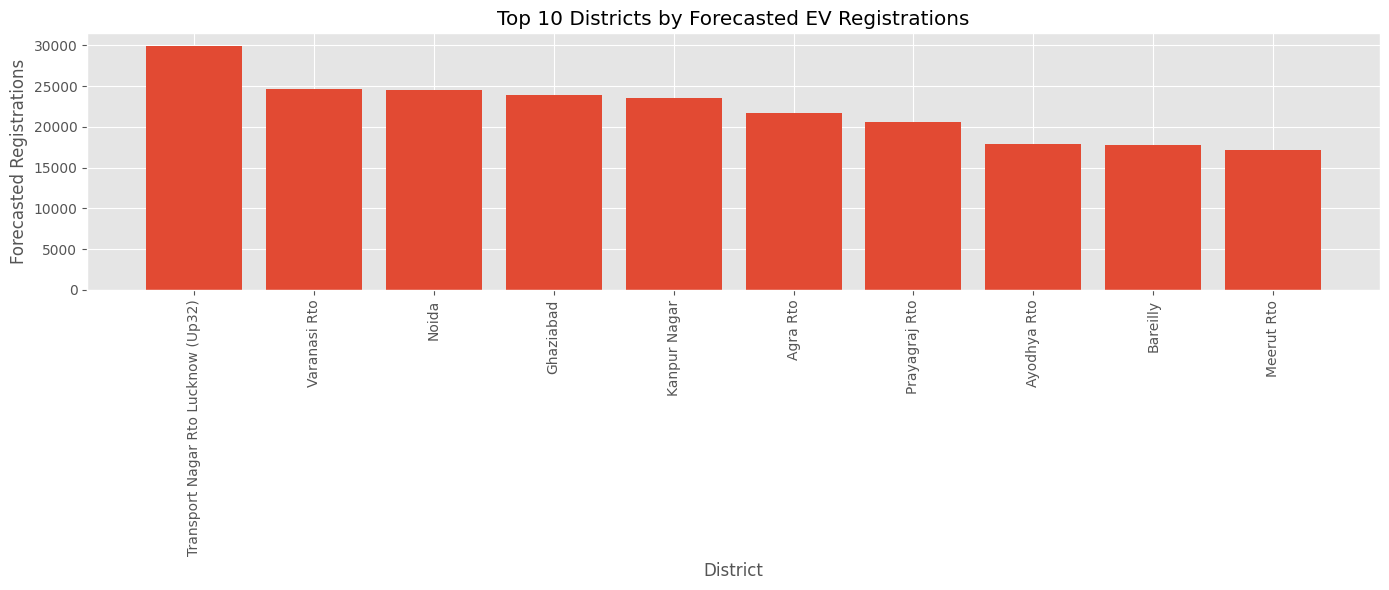

In [111]:
plt.figure(figsize=(14,6))

plt.bar(

    district_summary["District"][:10],

    district_summary["Forecasted EV Registrations"][:10]

)

plt.xticks(rotation=90)

plt.title("Top 10 Districts by Forecasted EV Registrations")

plt.xlabel("District")

plt.ylabel("Forecasted Registrations")

plt.tight_layout()

plt.show()

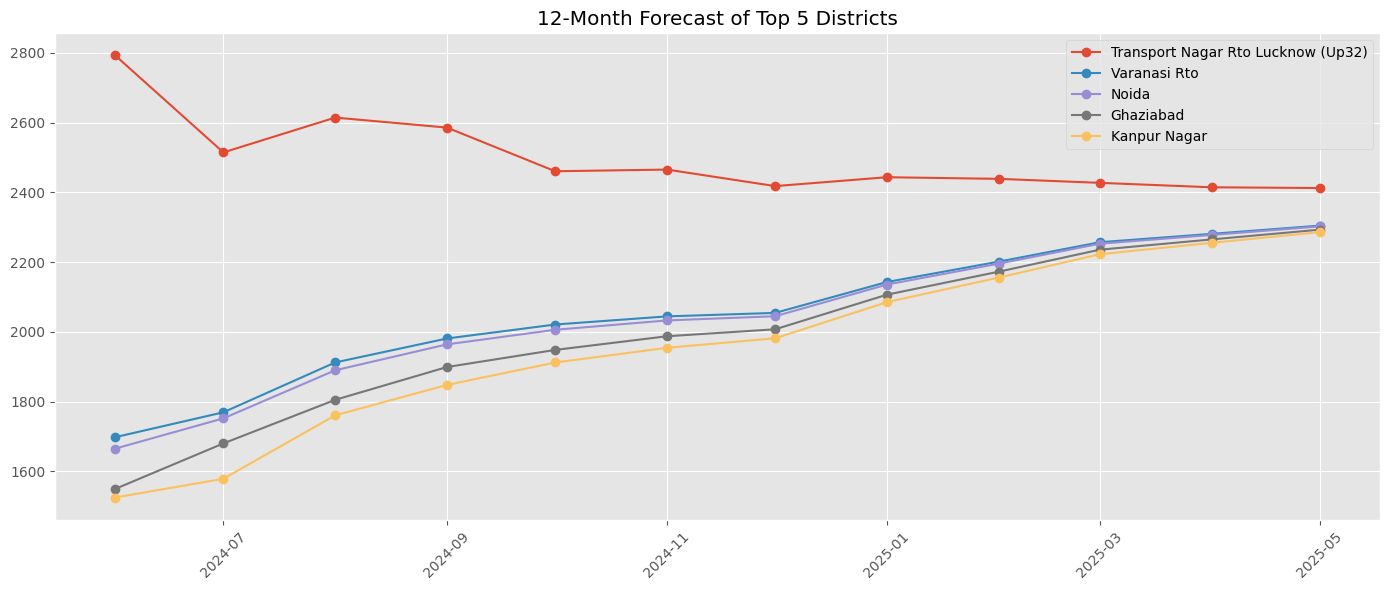

In [112]:
plt.figure(figsize=(14,6))

top5 = district_summary["District"][:5]

for district in top5:

    temp = forecast_df[
        forecast_df["office_name"] == district
    ]

    plt.plot(

        temp["date"],

        temp["monthly_registrations"],

        marker="o",

        label=district

    )

plt.legend()

plt.xticks(rotation=45)

plt.title("12-Month Forecast of Top 5 Districts")

plt.tight_layout()

plt.show()

In [113]:
district_summary.to_csv(

    "district_ranking.csv",

    index=False

)

In [114]:
print("Forecasting Completed Successfully.")

Forecasting Completed Successfully.
